In [1]:

import os, os.path
import warnings
import zipfile
import random
import io
import sys

import numpy as np
import pandas as pd
from tqdm import tqdm


from PIL import Image
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import image as mpimg


In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    ZIP_PATH = 'images_emotion.zip'
else:
    ZIP_PATH = '/content/drive/MyDrive/images_emotion.zip'
finally:
    assert os.path.isfile(ZIP_PATH)

Mounted at /content/drive


In [3]:
import zipfile
import os
from collections import defaultdict

def count_files_in_zip(zip_path, dir_name):
    with zipfile.ZipFile(zip_path, 'r') as archive:
        all_paths = [path for path in archive.namelist() if path.startswith(dir_name + '/')]
        emotions = set(os.path.split(path)[0] for path in all_paths if '/' in path)
        file_counts = defaultdict(int)
        for path in all_paths:
            for emotion in emotions:
                if path.startswith(emotion + '/'):
                    file_counts[emotion.split('/')[-1]] += 1
        return dict(file_counts)

# Count files in train and test directories
train_counts = count_files_in_zip(ZIP_PATH, 'train')
test_counts = count_files_in_zip(ZIP_PATH, 'test')

print("Train counts:", train_counts)
print("Test counts:", test_counts)


Train counts: {'angry': 3995, 'disgusted': 436, 'fearful': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprised': 3171}
Test counts: {'angry': 958, 'disgusted': 111, 'fearful': 1024, 'happy': 1774, 'neutral': 1233, 'sad': 1247, 'surprised': 831}


we can add analysis here of it, some pictures maybe

In [4]:
import zipfile
import io
from PIL import Image

def get_filenames_emotions_and_images(zip_path, dir_name):
    file_data = []
    images = []
    with zipfile.ZipFile(zip_path, 'r') as archive:
        for path in archive.namelist():
            if path.startswith(dir_name + '/') and path.count('/') == 2:
                emotion = path.split('/')[1]
                filename = path.split('/')[2]
                if filename:
                    with archive.open(path) as file:
                        buffer = io.BytesIO(file.read())
                        image = Image.open(buffer)
                        images.append(image)
                    file_data.append({'filename': filename, 'emotion': emotion})
    return file_data, images

train_data, train_images = get_filenames_emotions_and_images(ZIP_PATH, 'train')
test_data, test_images = get_filenames_emotions_and_images(ZIP_PATH, 'test')

train_df = pd.DataFrame(train_data)
train_df["image"] = pd.Series(train_images)
test_df = pd.DataFrame(test_data)
test_df["image"] = pd.Series(test_images)


In [5]:
from sklearn.model_selection import train_test_split
test_df, validation_df = train_test_split(test_df, test_size=0.25, random_state=42)



In [6]:
import random


images = ['image_data_{}'.format(i) for i in range(len(train_df))]

train_df = train_df.sample(frac=1, random_state=1234).reset_index(drop=True)

ordered_images = images[:]
for new_index, row in train_df.iterrows():
    images[new_index] = ordered_images[row.name]



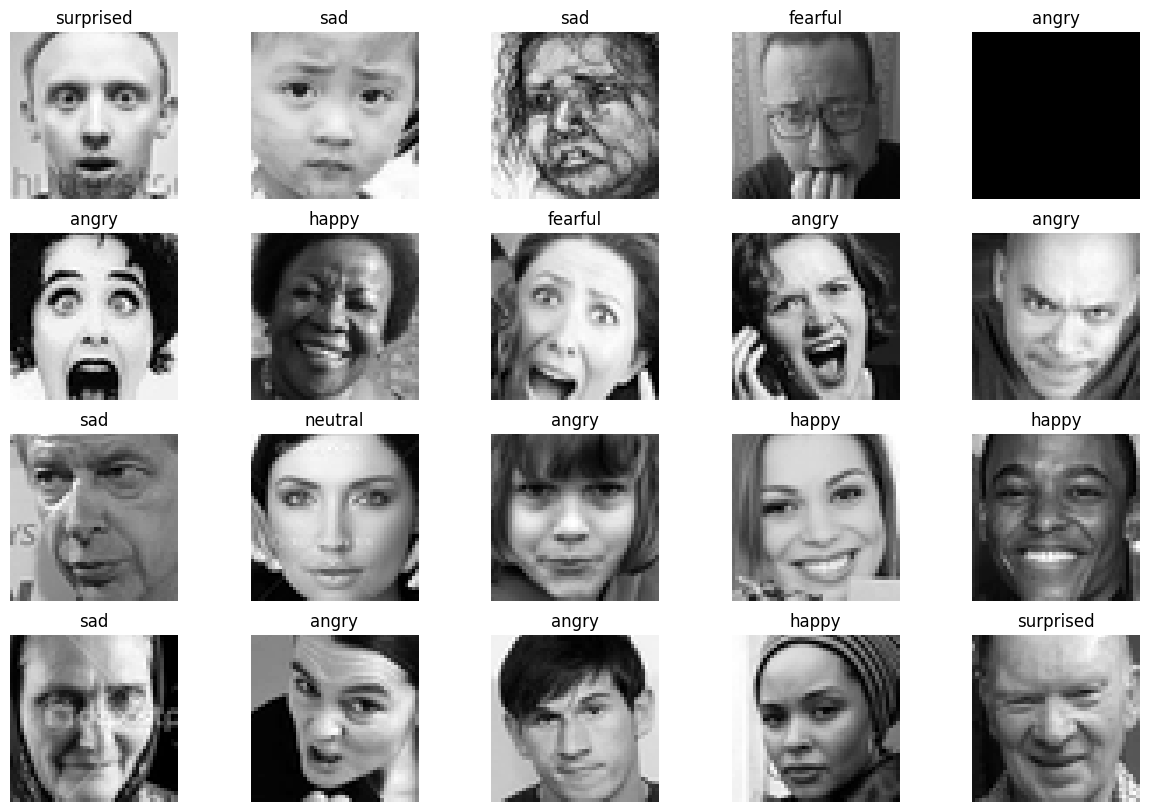

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

sampled_df = train_df.sample(n=20)

plt.figure(figsize=(15, 10))

for i, row in enumerate(sampled_df.itertuples(), 1):
    img = row.image
    emotion = row.emotion

    plt.subplot(4, 5, i)
    plt.imshow(img, cmap='gray')
    plt.title(emotion)
    plt.axis('off')

plt.show()


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import pandas as pd

In [9]:
def process_images(image_list, target_size=(48, 48)):
    processed_images = []
    for image in image_list:
        if not isinstance(image, tf.Tensor):
            image = tf.convert_to_tensor(image, dtype=tf.float32)
        if len(image.shape) == 2:
            image = tf.expand_dims(image, -1)
        image = tf.image.resize(image, target_size)
        if image.shape[-1] == 1:
            image = tf.image.grayscale_to_rgb(image)
        image = image / 255.0
        processed_images.append(image)
    return processed_images


test_df['image'] = process_images(test_df['image'].tolist())
train_df['image'] = process_images(train_df['image'].tolist())
validation_df['image'] = process_images(validation_df['image'].tolist())


test_labels = tf.keras.utils.to_categorical(test_df['emotion'].astype('category').cat.codes)
test_images = np.stack(test_df['image'].values)
test_dataset = tf.data.Dataset.from_tensor_slices((test_images, test_labels))
test_dataset = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

train_labels = tf.keras.utils.to_categorical(train_df['emotion'].astype('category').cat.codes)
train_images = np.stack(train_df['image'].values)
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
train_dataset = train_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

validation_labels = tf.keras.utils.to_categorical(validation_df['emotion'].astype('category').cat.codes)
validation_images = np.stack(validation_df['image'].values)
validation_dataset = tf.data.Dataset.from_tensor_slices((validation_images, validation_labels))
validation_dataset = validation_dataset.batch(32).prefetch(tf.data.AUTOTUNE)


In [10]:
# Convert labels to categorical one-hot encoding
num_classes = test_df['emotion'].nunique()  # Number of unique emotions

# Convert emotion labels to one-hot vectors
test_labels = to_categorical(test_df['emotion'].astype('category').cat.codes, num_classes)
validation_labels = to_categorical(validation_df['emotion'].astype('category').cat.codes, num_classes)
train_labels = to_categorical(train_df['emotion'].astype('category').cat.codes, num_classes)



In [11]:
def df_to_dataset(dataframe, labels, shuffle=True, batch_size=32):
    ds = tf.data.Dataset.from_tensor_slices((list(dataframe['image']), labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe))
    ds = ds.batch(batch_size)
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)
    return ds

batch_size = 32
test_dataset = df_to_dataset(test_df, test_labels, batch_size=batch_size)
validation_dataset = df_to_dataset(validation_df, validation_labels, batch_size=batch_size)
train_dataset = df_to_dataset(train_df, train_labels, batch_size=batch_size)

In [12]:
early_stopping = EarlyStopping(
    monitor='val_accuracy',  # Monitor the validation loss
    min_delta=0.001,     # Minimum change to qualify as an improvement
    patience=10,          # Stop after 5 epochs with no improvement
    verbose=1,           # Print messages when stopping
    mode='max',          # Minimize the monitored value (accuracy)
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

In [13]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
import keras
from keras.preprocessing import image
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten,Dense,Dropout,BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from tensorflow.keras.applications import VGG16, InceptionResNetV2
from keras import regularizers
from tensorflow.keras.optimizers import Adam,RMSprop,SGD,Adamax
from tensorflow.keras import models, layers, regularizers

model = models.Sequential([
    # First Convolutional Block with regular Conv2D
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(48, 48, 3), kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Second Block with Depthwise Separable Convolutions
    layers.SeparableConv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4)),
    layers.BatchNormalization(),
    layers.SeparableConv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Third Block with Depthwise Separable Convolutions and Residual Connections
    layers.SeparableConv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4)),
    layers.BatchNormalization(),
    layers.SeparableConv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    layers.Conv2D(128, (1, 1), padding='same', activation='relu'),  # Bottleneck layer for depth matching

    # Fourth Block with more depth
    layers.SeparableConv2D(256, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4)),
    layers.BatchNormalization(),
    layers.SeparableConv2D(256, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Fifth Block with highest depth
    layers.SeparableConv2D(512, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4)),
    layers.BatchNormalization(),
    layers.SeparableConv2D(512, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Flatten and Fully Connected Layers
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Model Summary
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=30
      # Add early stopping here for advanced models but decided we don't need it actually
)


Epoch 1/30
898/898 [==============================] - 25s 16ms/step - loss: 1.5874 - accuracy: 0.3747 - val_loss: 1.6710 - val_accuracy: 0.3706
Epoch 2/30
898/898 [==============================] - 12s 14ms/step - loss: 1.3494 - accuracy: 0.4847 - val_loss: 1.3272 - val_accuracy: 0.4863
Epoch 3/30
898/898 [==============================] - 12s 14ms/step - loss: 1.2624 - accuracy: 0.5206 - val_loss: 1.2999 - val_accuracy: 0.5142
Epoch 4/30
898/898 [==============================] - 15s 17ms/step - loss: 1.2006 - accuracy: 0.5455 - val_loss: 1.1949 - val_accuracy: 0.5452
Epoch 5/30
898/898 [==============================] - 13s 14ms/step - loss: 1.1586 - accuracy: 0.5650 - val_loss: 1.1328 - val_accuracy: 0.5673
Epoch 6/30
898/898 [==============================] - 13s 14ms/step - loss: 1.1232 - accuracy: 0.5749 - val_loss: 1.1371 - val_accuracy: 0.5712
Epoch 7/30
898/898 [==============================] - 13s 14ms/step - loss: 1.0955 - accuracy: 0.5882 - val_loss: 1.1089 - val_accuracy:

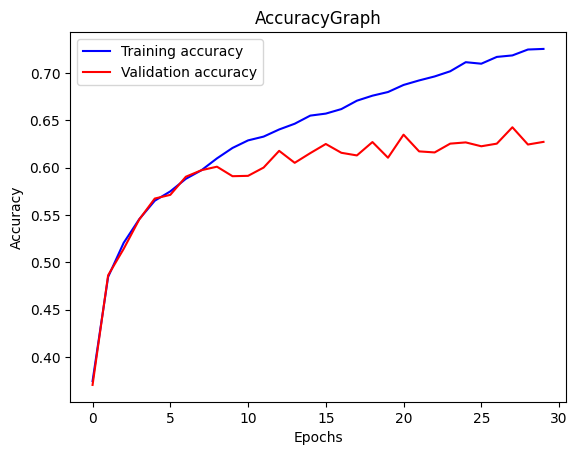

In [14]:
import matplotlib.pyplot as plt

epochs = len(history.history['loss'])

plt.plot(range(epochs), history.history['accuracy'], 'b', label='Training accuracy')
plt.plot(range(epochs), history.history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('AccuracyGraph')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [15]:
subset_validation_dataset = validation_dataset.take(500)

results = model.evaluate(subset_validation_dataset)
print(f"Test Loss, Test Accuracy: {results}")

57/57 [==============================] - 1s 12ms/step - loss: 1.1387 - accuracy: 0.6245
Test Loss, Test Accuracy: [1.138715386390686, 0.6245125532150269]


In [16]:
model.save('my_model.keras')

In [19]:
import numpy as np

y_true = []
y_pred = []

for images, labels in subset_validation_dataset:
    predictions = model.predict(images)
    y_pred.extend(np.argmax(predictions, axis=1))

    if labels.ndim > 1 and labels.shape[1] > 1:
        labels = np.argmax(labels, axis=1)
    y_true.extend(labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)



1/1 [==============================] - 0s 28ms/step


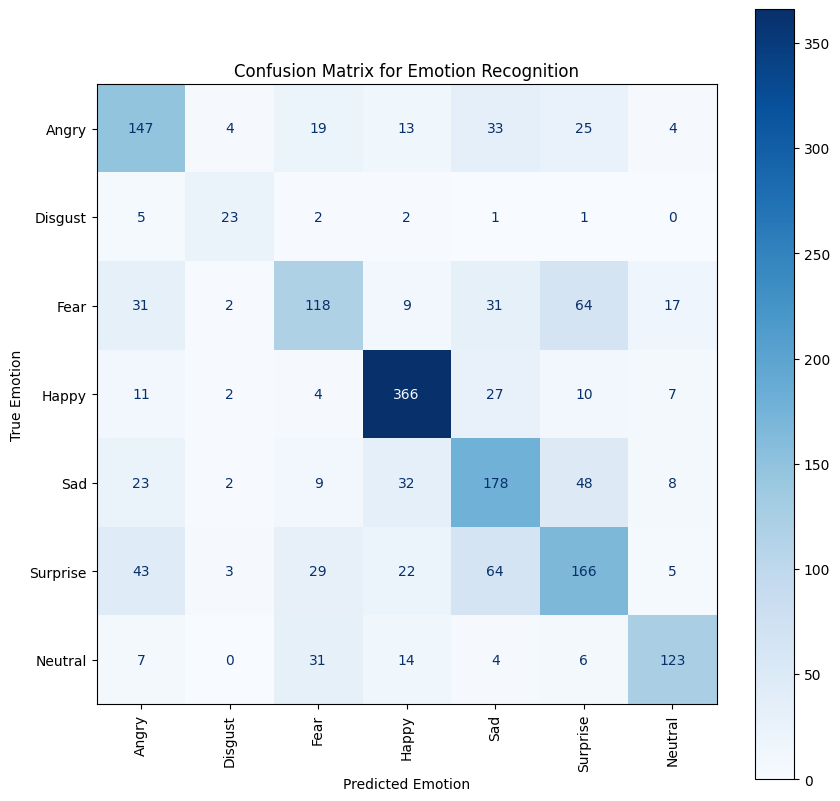

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_labels)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')

plt.title('Confusion Matrix for Emotion Recognition')
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.show()
